In [93]:
import jax
import jax.numpy as jnp
from jax import lax

%run ./eta.ipynb
%run ./contact.ipynb

def irr_elastic_eng(scattering_length, time_interval=1.0):
    a_s = jnp.asarray(scattering_length, dtype= jnp.float32)
    N = a_s.shape[0] - 1
    dt = time_interval / N

    eta = solve_eta(a_s, dt)

    enrgy_dens = energy_density(a_s, eta) 

    return enrgy_dens

def reg_elastic_eng(raw_a, a_max=20.0, time_interval=1.0):
    raw_a = jnp.asarray(raw_a, dtype= jnp.float32)
    a_bound = a_max * jax.nn.sigmoid(raw_a)
    return irr_elastic_eng(raw_a, time_interval)



Average function call time: 0.539298 s over 13 call(s).


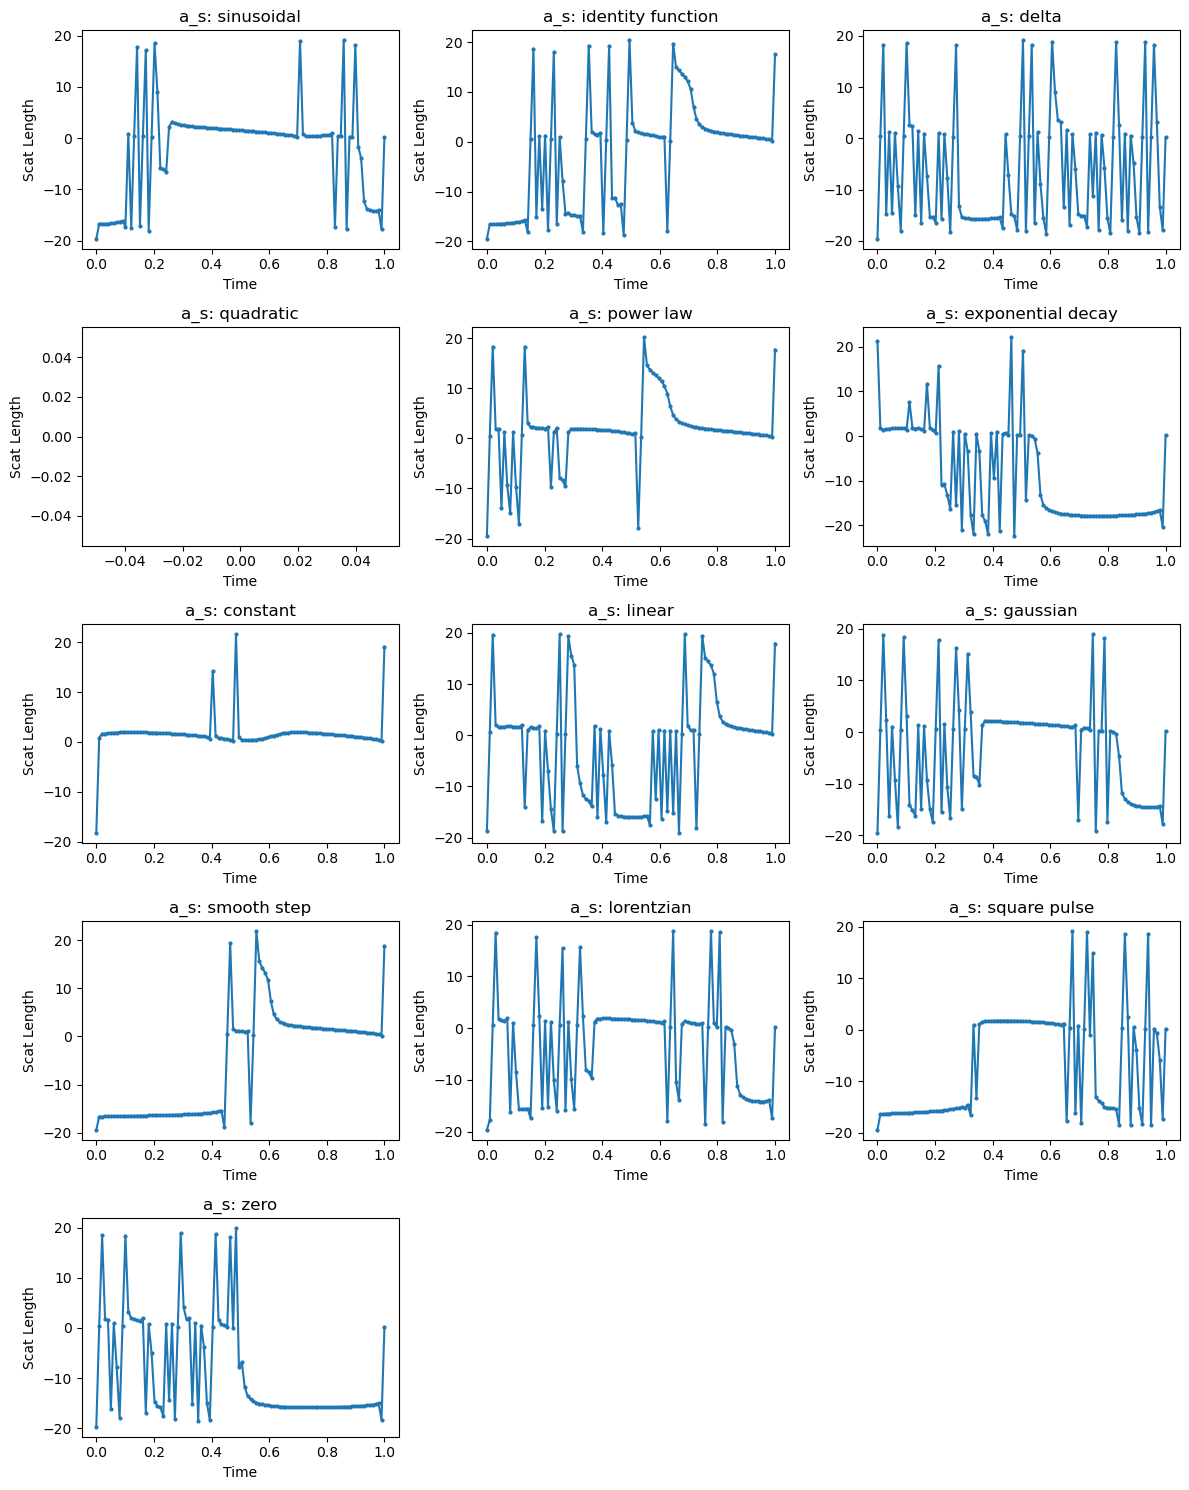

In [91]:
%run ./optimiser.ipynb

def loss_fn(params):
    return -irr_elastic_eng(params["a_s"])
    
def opt_irr_elastic(params):
    return optimise(loss_fn, params, steps=1000)

%run ./test.ipynb
test_run = run_random_tests(
    opt_irr_elastic,
    { 
        "a_s": {'name': "Scat Length", 'zeros': False},
    },
    array_length=100,
    plot_title="",
    plot_columns=3,
    make_plots=True,
)


Average function call time: 0.546616 s over 13 call(s).


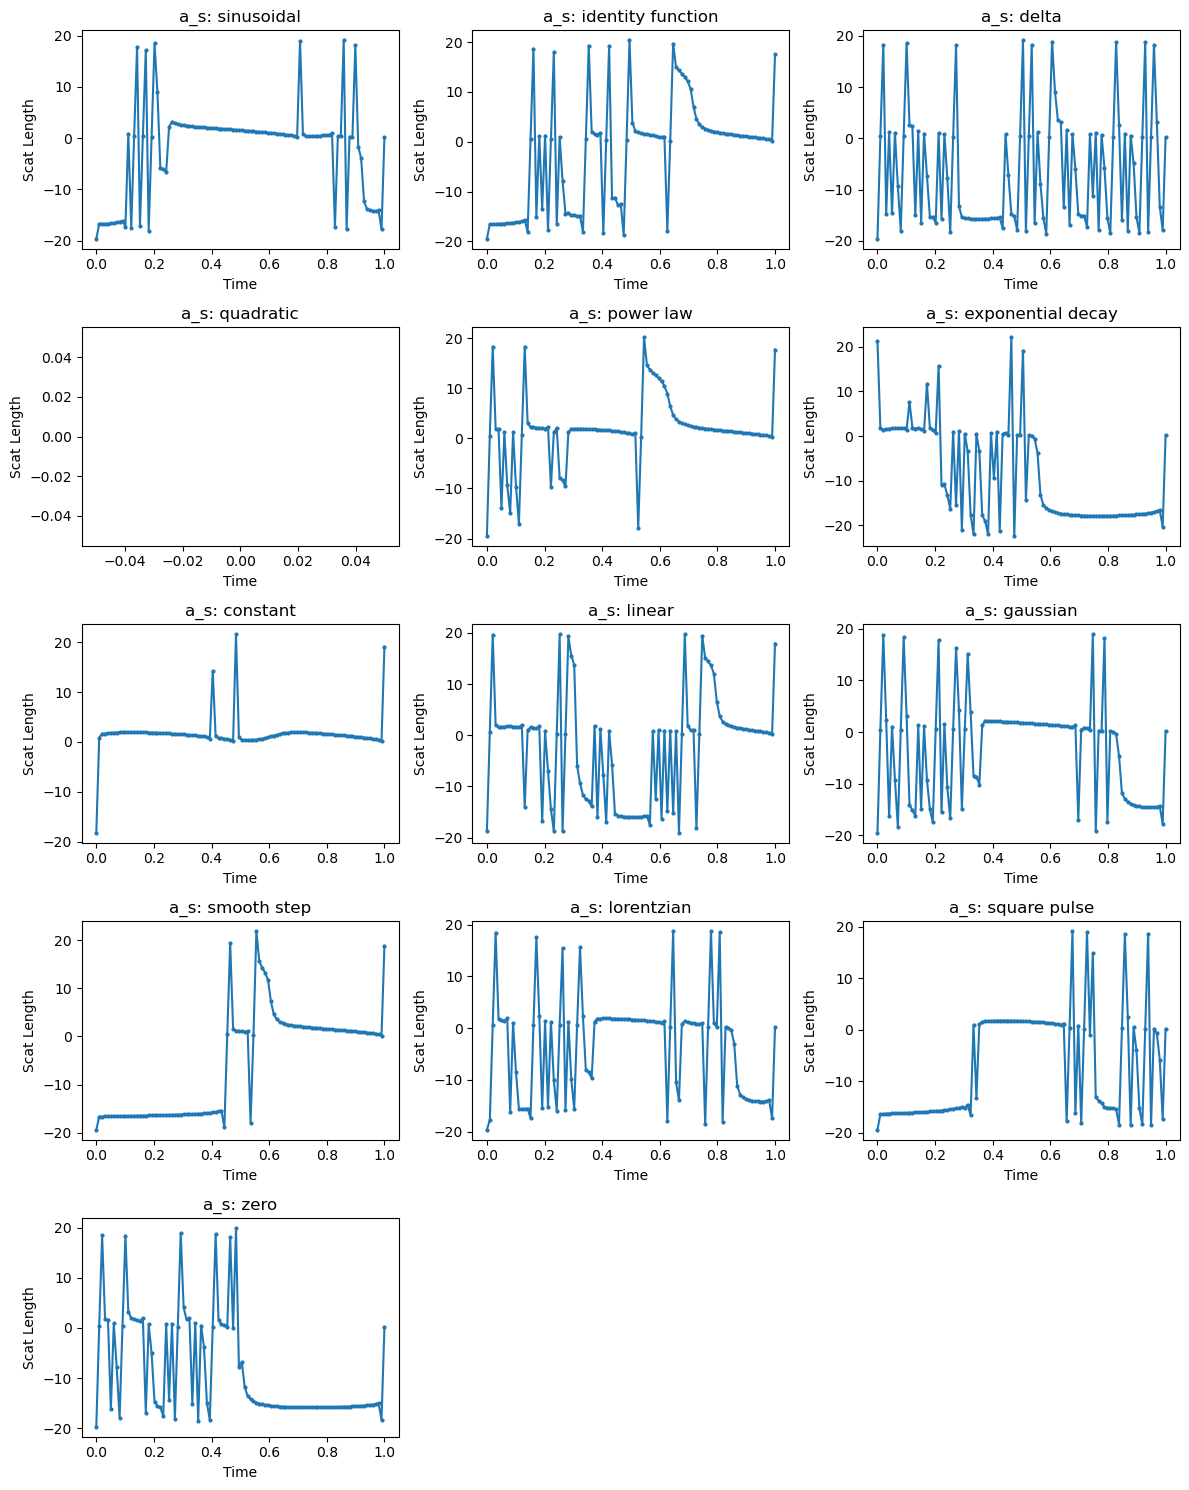

In [96]:
%run ./optimiser.ipynb

def loss_fn(params):
    return -reg_elastic_eng(params["a_s"])
    
def opt_reg_elastic(params):
    return optimise(loss_fn, params, steps=1000)

%run ./test.ipynb
test_run = run_random_tests(
    opt_reg_elastic,
    { 
        "a_s": {'name': "Scat Length", 'zeros': False},
    },
    array_length=100,
    plot_title="",
    plot_columns=3,
    make_plots=True,
)
